In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn 
import pandas as pd
import numpy as np
import ast
from datetime import datetime
from dateutil.relativedelta import relativedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load and Prepare Data

In [2]:
sales_purchases = pd.read_csv("missing_tax_type_taxpayer_sample_dataset_sales_and_purchases.csv")
taxpayers_tax_types_df = pd.read_csv("missing_tax_type_taxpayer_sample_dataset_registration.csv")


In [3]:
b2b_sales = sales_purchases[sales_purchases['b2b_sales_amount'].notna()]
b2b_sales
# purchases.to_excel("purchases_with_items.xlsx", index=False)

,masked_pin,month,year,month_year,b2b_nber_of_invoices,b2b_sales_amount,b2b_sold_items,b2c_nber_of_invoices,b2c_sales_amount,b2c_sold_items,purchases_nber_of_invoices,purchases_amount,purchased_items
3,fc0bd7e8c06b26f9470d22910924a3bbfebfb93c4bd8e6...,2025-04-01 00:00:00.000 +0300,2025,04/2025,1.0,150000.0,NaN,1.0,70000.00,NaN,1.0,154998.33,SUPER PETROL
4,d541af9a9e1a699a37f331d1826532b2c910a55ded8b6c...,2025-03-01 00:00:00.000 +0300,2025,03/2025,38.0,5896306.9,NaN,18.0,2741191.86,NaN,19.0,6225450.76,"Assorted Electrical Components, GENERAL SUPPLY..."
7,e7aa4f3f3abfdd9c7dff0f5d7365e9a202a383af887534...,2025-04-01 00:00:00.000 +0300,2025,04/2025,3.0,41975.0,NaN,0.0,0.00,NaN,1.0,5566.00,General Insurance
14,f7d9127b53f608afa47a697366f6532a0f31655059ebe9...,2025-05-01 00:00:00.000 +0300,2025,05/2025,6.0,484296.0,NaN,0.0,0.00,NaN,NaN,NaN,NaN
15,9fa011a90a58b3379a279d1353b2ebf42fb50254cf8004...,2025-02-01 00:00:00.000 +0300,2025,02/2025,18.0,420602.0,NaN,0.0,0.00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4609,000274e10e7df13daddc69a82b2fc6a9f36cd493c394a1...,2025-01-01 00:00:00.000 +0300,2025,01/2025,4.0,59160.0,NaN,0.0,0.00,NaN,NaN,NaN,NaN
4610,000274e10e7df13daddc69a82b2fc6a9f36cd493c394a1...,2025-03-01 00:00:00.000 +0300,2025,03/2025,2.0,55680.0,NaN,0.0,0.00,NaN,NaN,NaN,NaN
4611,0011033184d2380160f593f824aa0753fd82957bdaff09...,2025-03-01 00:00:00.000 +0300,2025,03/2025,0.0,0.0,NaN,3.0,162180.00,NaN,NaN,NaN,NaN
4612,0011033184d2380160f593f824aa0753fd82957bdaff09...,2025-04-01 00:00:00.000 +0300,2025,04/2025,0.0,0.0,NaN,5.0,141404.02,NaN,NaN,NaN,NaN


### Part 1: Calculating the sales to identify potential VAT taxpayers who are not on VAT

In [4]:
# ── Define the 12-month analysis window ───────────────────────────────────────
# Using a fixed rolling window (excluding the current partial month) ensures
# every taxpayer is evaluated over the same complete 12-month period.

window_end   = datetime.today().replace(day=1)       # First day of current month (exclusive upper bound)
window_start = window_end - relativedelta(months=24) # Same day, 12 months earlier

print(f"Analysis window: {window_start.strftime('%m/%Y')} to {(window_end - relativedelta(days=1)).strftime('%m/%Y')}")


Analysis window: 03/2024 to 02/2026


In [5]:
# ── Step 1: Filter sales data to the 12-month window ──────────────────────────

sales_purchases['month_dt'] = pd.to_datetime(sales_purchases['month']).dt.tz_convert(None)

sp_in_window = sales_purchases[
    (sales_purchases['month_dt'] >= window_start) &
    (sales_purchases['month_dt'] <  window_end)
]

# ── Step 2: Aggregate total sales and collect sold items per taxpayer ──────────
# Total sales = B2B invoiced sales + B2C sales

sales_agg = (
    sp_in_window
    .groupby('masked_pin')
    .agg(
        b2b_sales_amount =('b2b_sales_amount', 'sum'),
        b2c_sales_amount =('b2c_sales_amount', 'sum'),
        purchases_amount =('purchases_amount', 'sum'),
        b2b_sold_items   =('b2b_sold_items',   lambda x: list(map(str, x))),
        b2c_sold_items   =('b2c_sold_items',   lambda x: list(map(str, x))),
        purchased_items   =('purchased_items',   lambda x: list(map(str, x))),
    )
    .reset_index()
)

sales_agg['Total Sales'] = sales_agg['b2b_sales_amount'] + sales_agg['b2c_sales_amount']

# Combine B2B and B2C item lists into a single list of all sold items
sales_agg['Sold Items'] = sales_agg['b2b_sold_items'] + sales_agg['b2c_sold_items']
sales_agg['all_items'] = sales_agg['b2b_sold_items'] + sales_agg['b2c_sold_items'] + sales_agg['purchased_items']

# ── Step 3: Exclude taxpayers already registered on VAT ───────────────────────

already_on_vat = taxpayers_tax_types_df[taxpayers_tax_types_df['vat'].notna()]


# not_on_vat = sales_agg
not_on_vat = sales_agg[
    ~sales_agg['masked_pin'].astype(str).isin(already_on_vat['masked_pin'].astype(str))
]

# ── Step 4: Keep only those who exceeded the KES 5M VAT registration threshold ─

VAT_THRESHOLD = 500000  # KES 5 million

qualify_for_vat = (
    not_on_vat[not_on_vat['Total Sales'] >= VAT_THRESHOLD]
    [['masked_pin', 'Total Sales', 'b2b_sales_amount', 'b2c_sales_amount', 'Sold Items','all_items']]
    .rename(columns={
        'masked_pin':        'PIN',
        'b2b_sales_amount':  'B2B Sales',
        'b2c_sales_amount':  'B2C Sales',
        'purchases_amount':  'Purchases',
    })
    .sort_values('Total Sales', ascending=False)
    .reset_index(drop=True)
)

period_label = f"{window_start.strftime('%m/%Y')} – {(window_end - relativedelta(days=1)).strftime('%m/%Y')}"
qualify_for_vat['Analysis Period'] = period_label

print(f"Taxpayers exceeding KES 5M in sales and not yet on VAT: {len(qualify_for_vat):,}")
qualify_for_vat


Taxpayers exceeding KES 5M in sales and not yet on VAT: 264


,PIN,Total Sales,B2B Sales,B2C Sales,Sold Items,all_items,Analysis Period
0,455b3b99fcd7bb2f6304f40c73d0a9b641d9561ef4275f...,9.472283e+12,9.472283e+12,0.000000e+00,"[nan, nan]","[nan, nan, nan]",03/2024 – 02/2026
1,4fdb39d082f2fd8e75f71738a75ebf863234d5fe6f3279...,1.475449e+08,5.068637e+06,1.424762e+08,"[nan, nan]","[nan, nan, Consulting, General Insurance, Data...",03/2024 – 02/2026
2,ae45b74bab16bf0548c6edc4f88daa73e5a7143c47d4c3...,1.334768e+08,1.145171e+07,1.220251e+08,"[nan, nan]","[nan, nan, RAVINE'S GOLD ESL 500 ML, RAVINE'S ...",03/2024 – 02/2026
3,113a33498dbf2a197cbd99e7683887f52fd7a60370a247...,9.467540e+07,0.000000e+00,9.467540e+07,"[nan, nan]","[nan, nan, Air Ticketing, Air Ticketing, FACIL...",03/2024 – 02/2026
4,ba89f236a01a5fc9b8417423c948da50a271ed5a31290b...,8.871112e+07,6.777191e+06,8.193393e+07,"[nan, nan]","[nan, nan, Supply of vegetables, DStv Business...",03/2024 – 02/2026
...,...,...,...,...,...,...,...
259,308499c51d248a8a5b9538343dd7560006e74d2f938173...,5.187100e+05,5.187100e+05,0.000000e+00,"[nan, nan]","[nan, nan, nan]",03/2024 – 02/2026
260,e24498a81107562584301354722469aa36a668efad2290...,5.178630e+05,5.178630e+05,0.000000e+00,"[nan, nan]","[nan, nan, nan]",03/2024 – 02/2026
261,001500f35903a366dba11e3ffc8c8815e3d0886d7e9b83...,5.070377e+05,5.070377e+05,0.000000e+00,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",03/2024 – 02/2026
262,eae59a94d38b609af38fa8bdbb2aec9a6cf332fcd20f4d...,5.000000e+05,5.000000e+05,0.000000e+00,"[nan, nan]","[nan, nan, nan]",03/2024 – 02/2026


### Part 2: Using spacy to go through items and identify if they are subject to VAT or not.

In [6]:

# Adapt qualify_for_vat from Part 1 into the format expected by Part 2
raw_df = qualify_for_vat.rename(columns={
    'PIN':          'supplier_tin',
    'Total Sales':  'total_sales_amount',
    'all_items':   'ItemName' ## Here we decide to use 'all_items' which includes both sold and purchased items for a more comprehensive view of taxpayer activity. This may help in better understanding the nature of their business and improving the accuracy of VAT qualification predictions.
}).copy()

print(f"Raw data shape: {raw_df.shape}")

# Parse ItemName column.
# Each entry is already a Python list; elements may themselves be string-encoded lists (e.g. "['Cement', 'Tiles']") from the aggregation step.
def parse_item_list(item_value):
    items = item_value if isinstance(item_value, list) else [item_value]
    result = []
    for entry in items:
        try:
            parsed = ast.literal_eval(str(entry))
            result.extend(parsed if isinstance(parsed, list) else [str(parsed)])
        except Exception:
            result.append(str(entry))
    return result

raw_df['ItemName_list'] = raw_df['ItemName'].apply(parse_item_list)

items_data = []
for _, row in raw_df.iterrows():
    for item in row['ItemName_list']:
        if item is not None:
            items_data.append({
                'supplier_tin':      row['supplier_tin'],
                'item':              str(item).strip().lower(),
                'total_sales_amount': row['total_sales_amount']
            })

items_df = pd.DataFrame(items_data)
items_df = items_df[items_df['item'].str.len() > 0]
print(f"Items extracted: {len(items_df)}")


Raw data shape: (264, 7)
Items extracted: 1422


Define keyword rules for weak labels

In [7]:
vat_classification_data = [

    # VAT TAXABLE – Construction & Building Materials
    ('cement', 'VAT_TAXABLE'),
    ('construction materials', 'VAT_TAXABLE'),
    ('building materials', 'VAT_TAXABLE'),
    ('hardware materials', 'VAT_TAXABLE'),
    ('hardware items', 'VAT_TAXABLE'),
    ('quarry stones', 'VAT_TAXABLE'),
    ('ballast', 'VAT_TAXABLE'),
    ('river sand', 'VAT_TAXABLE'),
    ('gravel', 'VAT_TAXABLE'),
    ('wall tiles', 'VAT_TAXABLE'),
    ('floor tiles', 'VAT_TAXABLE'),
    ('ceramic adhesive', 'VAT_TAXABLE'),
    ('skim coat', 'VAT_TAXABLE'),
    ('paint', 'VAT_TAXABLE'),
    ('mdf board', 'VAT_TAXABLE'),
    ('plywood', 'VAT_TAXABLE'),
    ('gypsum ceiling', 'VAT_TAXABLE'),
    ('iron sheet', 'VAT_TAXABLE'),
    ('roofing', 'VAT_TAXABLE'),
    ('structural steel', 'VAT_TAXABLE'),
    ('hdpe pipe', 'VAT_TAXABLE'),
    ('pipes', 'VAT_TAXABLE'),
    ('plumbing items', 'VAT_TAXABLE'),
    ('timber', 'VAT_TAXABLE'),
    ('nails', 'VAT_TAXABLE'),
    ('screws', 'VAT_TAXABLE'),
    ('electrical components', 'VAT_TAXABLE'),
    ('lighting accessories', 'VAT_TAXABLE'),
    ('construction service', 'VAT_TAXABLE'),
    ('civil masonry works', 'VAT_TAXABLE'),
    ('delivery charges', 'VAT_TAXABLE'),

    # VAT TAXABLE – Electronics & IT Equipment
    ('electronics', 'VAT_TAXABLE'),
    ('laptop', 'VAT_TAXABLE'),
    ('computer', 'VAT_TAXABLE'),
    ('printer', 'VAT_TAXABLE'),
    ('scanner', 'VAT_TAXABLE'),
    ('photocopier', 'VAT_TAXABLE'),
    ('toner', 'VAT_TAXABLE'),
    ('cartridge', 'VAT_TAXABLE'),
    ('router', 'VAT_TAXABLE'),
    ('camera', 'VAT_TAXABLE'),
    ('television', 'VAT_TAXABLE'),
    ('smart tv', 'VAT_TAXABLE'),
    ('mobile phone', 'VAT_TAXABLE'),
    ('smartphone', 'VAT_TAXABLE'),
    ('samsung', 'VAT_TAXABLE'),
    ('tablet', 'VAT_TAXABLE'),
    ('memory card', 'VAT_TAXABLE'),
    ('flash disk', 'VAT_TAXABLE'),
    ('hard drive', 'VAT_TAXABLE'),
    ('computer accessories', 'VAT_TAXABLE'),
    ('ict products', 'VAT_TAXABLE'),
    ('ups', 'VAT_TAXABLE'),
    ('generator', 'VAT_TAXABLE'),
    ('solar equipment', 'VAT_TAXABLE'),
    ('earphones', 'VAT_TAXABLE'),

    # VAT TAXABLE – Software & Digital Services
    ('software license', 'VAT_TAXABLE'),
    ('saas', 'VAT_TAXABLE'),
    ('cloud services', 'VAT_TAXABLE'),
    ('internet services', 'VAT_TAXABLE'),
    ('web development', 'VAT_TAXABLE'),
    ('web design', 'VAT_TAXABLE'),
    ('airtime', 'VAT_TAXABLE'),
    ('dstv', 'VAT_TAXABLE'),
    ('data analytics service', 'VAT_TAXABLE'),

    # VAT TAXABLE – Professional & Business Services
    ('consultancy', 'VAT_TAXABLE'),
    ('consulting', 'VAT_TAXABLE'),
    ('management fees', 'VAT_TAXABLE'),
    ('audit services', 'VAT_TAXABLE'),
    ('bookkeeping', 'VAT_TAXABLE'),
    ('company secretarial', 'VAT_TAXABLE'),
    ('office administration', 'VAT_TAXABLE'),
    ('project consultancy', 'VAT_TAXABLE'),
    ('general supplies', 'VAT_TAXABLE'),
    ('assorted goods', 'VAT_TAXABLE'),

    # VAT TAXABLE – Transport & Logistics Services
    ('transport services', 'VAT_TAXABLE'),
    ('transport of cargo', 'VAT_TAXABLE'),
    ('pick up and delivery', 'VAT_TAXABLE'),
    ('freight', 'VAT_TAXABLE'),
    ('shipping services', 'VAT_TAXABLE'),
    ('courier', 'VAT_TAXABLE'),
    ('towing services', 'VAT_TAXABLE'),
    ('clearing', 'VAT_TAXABLE'),
    ('forwarding', 'VAT_TAXABLE'),
    ('agency fee', 'VAT_TAXABLE'),
    ('port charges', 'VAT_TAXABLE'),
    ('air freight', 'VAT_TAXABLE'),

    # VAT TAXABLE – Commercial Rental & Accommodation
    ('accommodation', 'VAT_TAXABLE'),
    ('commercial rent', 'VAT_TAXABLE'),
    ('office rent', 'VAT_TAXABLE'),
    ('rental income', 'VAT_TAXABLE'),
    ('monthly rent receivable', 'VAT_TAXABLE'),

    # VAT TAXABLE – Hotel, Restaurant & Catering
    ('restaurant', 'VAT_TAXABLE'),
    ('meals', 'VAT_TAXABLE'),
    ('lunch', 'VAT_TAXABLE'),
    ('dinner', 'VAT_TAXABLE'),
    ('breakfast', 'VAT_TAXABLE'),
    ('food and drinks', 'VAT_TAXABLE'),
    ('buffet', 'VAT_TAXABLE'),
    ('conference services', 'VAT_TAXABLE'),
    ('conference room', 'VAT_TAXABLE'),
    ('conference hall', 'VAT_TAXABLE'),
    ('teabreak', 'VAT_TAXABLE'),
    ('catering', 'VAT_TAXABLE'),

    # VAT TAXABLE – Processed Food & Grocery
    ('soft drinks', 'VAT_TAXABLE'),
    ('energy drink', 'VAT_TAXABLE'),
    ('juice', 'VAT_TAXABLE'),
    ('beverage', 'VAT_TAXABLE'),
    ('beer', 'VAT_TAXABLE'),
    ('alcohol', 'VAT_TAXABLE'),
    ('liquor', 'VAT_TAXABLE'),
    ('cooking oil', 'VAT_TAXABLE'),
    ('sugar', 'VAT_TAXABLE'),
    ('wheat flour', 'VAT_TAXABLE'),
    ('spaghetti', 'VAT_TAXABLE'),
    ('pasta', 'VAT_TAXABLE'),
    ('biscuit', 'VAT_TAXABLE'),
    ('chocolate', 'VAT_TAXABLE'),
    ('ice cream', 'VAT_TAXABLE'),
    ('uht milk', 'VAT_TAXABLE'),
    ('coffee', 'VAT_TAXABLE'),
    ('tea', 'VAT_TAXABLE'),
    ('tomato paste', 'VAT_TAXABLE'),
    ('mayonnaise', 'VAT_TAXABLE'),
    ('vinegar', 'VAT_TAXABLE'),
    ('crisps', 'VAT_TAXABLE'),
    ('bakery', 'VAT_TAXABLE'),
    ('soap', 'VAT_TAXABLE'),
    ('detergent', 'VAT_TAXABLE'),
    ('toilet paper', 'VAT_TAXABLE'),
    ('body lotion', 'VAT_TAXABLE'),
    ('shampoo', 'VAT_TAXABLE'),
    ('liquid soap', 'VAT_TAXABLE'),
    ('washing machine', 'VAT_TAXABLE'),

    # VAT TAXABLE – Motor Vehicles, Repairs & Spare Parts
    ('motor vehicle', 'VAT_TAXABLE'),
    ('spare parts', 'VAT_TAXABLE'),
    ('tyres', 'VAT_TAXABLE'),
    ('vehicle repair', 'VAT_TAXABLE'),
    ('repair services', 'VAT_TAXABLE'),
    ('motor vehicle body repair', 'VAT_TAXABLE'),

    # VAT TAXABLE – Printing, Stationery & Packaging
    ('printing materials', 'VAT_TAXABLE'),
    ('graphic design', 'VAT_TAXABLE'),
    ('stationery', 'VAT_TAXABLE'),
    ('branding', 'VAT_TAXABLE'),
    ('billboard', 'VAT_TAXABLE'),
    ('packaging', 'VAT_TAXABLE'),
    ('plastic bags', 'VAT_TAXABLE'),
    ('carrier bags', 'VAT_TAXABLE'),
    ('notebook', 'VAT_TAXABLE'),

    # VAT TAXABLE – Security & Facilities Services
    ('security guards', 'VAT_TAXABLE'),
    ('guarding services', 'VAT_TAXABLE'),
    ('security service', 'VAT_TAXABLE'),
    ('garbage collection', 'VAT_TAXABLE'),
    ('car wash', 'VAT_TAXABLE'),
    ('laundry cleaning services', 'VAT_TAXABLE'),
    ('ac servicing', 'VAT_TAXABLE'),

    # VAT TAXABLE – Electricity
    ('electricity bill', 'VAT_TAXABLE'),
    ('fuel cost charge', 'VAT_TAXABLE'),
    ('erc levy', 'VAT_TAXABLE'),

    # VAT TAXABLE – Advertising & Creative Services
    ('advertising', 'VAT_TAXABLE'),
    ('marketing', 'VAT_TAXABLE'),
    ('photography', 'VAT_TAXABLE'),
    ('videography', 'VAT_TAXABLE'),
    ('video production', 'VAT_TAXABLE'),
    ('event venue', 'VAT_TAXABLE'),

    # VAT TAXABLE – Furniture & Household Goods
    ('furniture', 'VAT_TAXABLE'),
    ('household items', 'VAT_TAXABLE'),
    ('diaper', 'VAT_TAXABLE'),
    ('first aid kit', 'VAT_TAXABLE'),

    # VAT TAXABLE – Import / Customs Related
    ('customs duty', 'VAT_TAXABLE'),
    ('import duty', 'VAT_TAXABLE'),

    # VAT EXEMPT – Insurance & Financial Services
    ('insurance premium', 'VAT_EXEMPT'),
    ('insurance policy', 'VAT_EXEMPT'),
    ('insurance policies', 'VAT_EXEMPT'),
    ('general insurance', 'VAT_EXEMPT'),
    ('insurance service', 'VAT_EXEMPT'),
    ('insurance cover', 'VAT_EXEMPT'),
    ('gross premium', 'VAT_EXEMPT'),
    ('motor insurance', 'VAT_EXEMPT'),
    ('motor private', 'VAT_EXEMPT'),
    ('motor commercial', 'VAT_EXEMPT'),
    ('health insurance', 'VAT_EXEMPT'),
    ('life insurance', 'VAT_EXEMPT'),
    ('personal accident', 'VAT_EXEMPT'),
    ('underwriting', 'VAT_EXEMPT'),
    ('reinsurance', 'VAT_EXEMPT'),
    ('interest income', 'VAT_EXEMPT'),
    ('bank interest', 'VAT_EXEMPT'),
    ('bank charges', 'VAT_EXEMPT'),
    ('loan repayment', 'VAT_EXEMPT'),

    # VAT EXEMPT – Water & Sanitation Services
    ('water monthly bill', 'VAT_EXEMPT'),
    ('water bill', 'VAT_EXEMPT'),
    ('water supply', 'VAT_EXEMPT'),
    ('water reconnection', 'VAT_EXEMPT'),
    ('sewer charges', 'VAT_EXEMPT'),
    ('sewerage', 'VAT_EXEMPT'),
    ('sewage', 'VAT_EXEMPT'),
    ('conservancy fee', 'VAT_EXEMPT'),
    ('standing charges', 'VAT_EXEMPT'),
    ('meter rent', 'VAT_EXEMPT'),
    ('refuse', 'VAT_EXEMPT'),
    ('warma levy', 'VAT_EXEMPT'),

    # VAT EXEMPT – Medical & Healthcare Services
    ('medical services', 'VAT_EXEMPT'),
    ('healthcare services', 'VAT_EXEMPT'),
    ('medical care', 'VAT_EXEMPT'),
    ('outpatient services', 'VAT_EXEMPT'),
    ('inpatient', 'VAT_EXEMPT'),
    ('hospital', 'VAT_EXEMPT'),
    ('dental services', 'VAT_EXEMPT'),
    ('dental anaesthesia', 'VAT_EXEMPT'),
    ('scaling and polishing', 'VAT_EXEMPT'),
    ('physiotherapy', 'VAT_EXEMPT'),
    ('medical consultation', 'VAT_EXEMPT'),
    ('general consultation', 'VAT_EXEMPT'),
    ('paediatrician', 'VAT_EXEMPT'),
    ('radiology', 'VAT_EXEMPT'),
    ('ct scan', 'VAT_EXEMPT'),
    ('blood count', 'VAT_EXEMPT'),
    ('full haemogram', 'VAT_EXEMPT'),
    ('urinalysis', 'VAT_EXEMPT'),
    ('laboratory services', 'VAT_EXEMPT'),
    ('medical bill', 'VAT_EXEMPT'),
    ('medical treatment', 'VAT_EXEMPT'),
    ('medical examination', 'VAT_EXEMPT'),

    # VAT EXEMPT – Pharmaceutical Products
    ('human drugs', 'VAT_EXEMPT'),
    ('pharmaceuticals', 'VAT_EXEMPT'),
    ('paracetamol', 'VAT_EXEMPT'),
    ('amoxycillin', 'VAT_EXEMPT'),
    ('azithromycin', 'VAT_EXEMPT'),
    ('ibuprofen', 'VAT_EXEMPT'),
    ('diclofenac', 'VAT_EXEMPT'),
    ('metformin', 'VAT_EXEMPT'),
    ('atenolol', 'VAT_EXEMPT'),
    ('prednisolone', 'VAT_EXEMPT'),
    ('metronidazole', 'VAT_EXEMPT'),
    ('cotrimoxazole', 'VAT_EXEMPT'),
    ('coartem', 'VAT_EXEMPT'),
    ('mebendazole', 'VAT_EXEMPT'),
    ('albendazole', 'VAT_EXEMPT'),
    ('tetracycline', 'VAT_EXEMPT'),
    ('erythromycin', 'VAT_EXEMPT'),
    ('ketoconazole', 'VAT_EXEMPT'),
    ('eye drops', 'VAT_EXEMPT'),
    ('ear drops', 'VAT_EXEMPT'),
    ('insulin', 'VAT_EXEMPT'),
    ('vaccine', 'VAT_EXEMPT'),
    ('syringes', 'VAT_EXEMPT'),
    ('surgical blades', 'VAT_EXEMPT'),
    ('panadol', 'VAT_EXEMPT'),
    ('omeprazole', 'VAT_EXEMPT'),
    ('acyclovir', 'VAT_EXEMPT'),
    ('hyoscine', 'VAT_EXEMPT'),
    ('lactulose', 'VAT_EXEMPT'),
    ('elastoplast', 'VAT_EXEMPT'),
    ('micropore tape', 'VAT_EXEMPT'),

    # VAT EXEMPT – Educational Services
    ('education services', 'VAT_EXEMPT'),
    ('school fees', 'VAT_EXEMPT'),
    ('tuition fees', 'VAT_EXEMPT'),
    ('college training', 'VAT_EXEMPT'),

    # VAT EXEMPT – Unprocessed Agricultural Produce
    ('fresh vegetables', 'VAT_EXEMPT'),
    ('supply of vegetables', 'VAT_EXEMPT'),
    ('fresh fruits', 'VAT_EXEMPT'),
    ('fruits and vegetables', 'VAT_EXEMPT'),
    ('onions', 'VAT_EXEMPT'),
    ('spinach', 'VAT_EXEMPT'),
    ('french beans', 'VAT_EXEMPT'),
    ('capsicum', 'VAT_EXEMPT'),
    ('butternut', 'VAT_EXEMPT'),
    ('strawberries', 'VAT_EXEMPT'),
    ('maize grain', 'VAT_EXEMPT'),
    ('sorghum', 'VAT_EXEMPT'),
    ('certified beans', 'VAT_EXEMPT'),
    ('eggs', 'VAT_EXEMPT'),
    ('fresh tilapia', 'VAT_EXEMPT'),
    ('fish fillets', 'VAT_EXEMPT'),
    ('jumbo prawns', 'VAT_EXEMPT'),
    ('boneless chicken', 'VAT_EXEMPT'),
    ('chicken breast', 'VAT_EXEMPT'),
    ('goat leg', 'VAT_EXEMPT'),
    ('lamb mince', 'VAT_EXEMPT'),
    ('pork chops', 'VAT_EXEMPT'),

    # VAT EXEMPT – Agricultural Inputs
    ('animal feed', 'VAT_EXEMPT'),
    ('cattle feed', 'VAT_EXEMPT'),
    ('poultry feed', 'VAT_EXEMPT'),
    ('broiler starter', 'VAT_EXEMPT'),
    ('broiler finisher', 'VAT_EXEMPT'),
    ('layer feed', 'VAT_EXEMPT'),
    ('day old chick', 'VAT_EXEMPT'),
    ('soya bean meal', 'VAT_EXEMPT'),
    ('fertiliser', 'VAT_EXEMPT'),
    ('fertilizer', 'VAT_EXEMPT'),
    ('pesticide', 'VAT_EXEMPT'),
    ('insecticide', 'VAT_EXEMPT'),
    ('herbicide', 'VAT_EXEMPT'),
    ('certified seeds', 'VAT_EXEMPT'),
    ('farm inputs', 'VAT_EXEMPT'),

    # VAT EXEMPT – Residential Accommodation
    ('residential rent', 'VAT_EXEMPT'),
    ('residential services', 'VAT_EXEMPT'),

    # VAT EXEMPT – Legal Services
    ('legal services', 'VAT_EXEMPT'),
    ('legal advisory', 'VAT_EXEMPT'),
    ('legal advice', 'VAT_EXEMPT'),

    # VAT EXEMPT – Veterinary Services
    ('veterinary services', 'VAT_EXEMPT'),
    ('vet services', 'VAT_EXEMPT'),

    # VAT TAXABLE – Fuel & Petroleum Products
    ('diesel', 'VAT_TAXABLE'),
    ('petrol', 'VAT_TAXABLE'),
    ('super petrol', 'VAT_TAXABLE'),
    ('fuel', 'VAT_TAXABLE'),
    ('lubricants', 'VAT_TAXABLE'),
    ('kerosene', 'VAT_TAXABLE'),
    ('lpg gas', 'VAT_TAXABLE'),
    ('motor oil', 'VAT_TAXABLE'),
    ('petroleum oils', 'VAT_TAXABLE'),
    ('low sulphur diesel', 'VAT_TAXABLE')

    
]

# Extract keywords for keyword-based classification
vat_exempt_keywords = {keyword for keyword, status in vat_classification_data if status == 'VAT_EXEMPT'}
vat_taxable_keywords = {keyword for keyword, status in vat_classification_data if status == 'VAT_TAXABLE'}

print(f"VAT_EXEMPT  keywords : {len(vat_exempt_keywords)}")
print(f"VAT_TAXABLE keywords : {len(vat_taxable_keywords)}")
print(f"Total entries        : {len(vat_classification_data)}")

VAT_EXEMPT  keywords : 132
VAT_TAXABLE keywords : 181
Total entries        : 313


In [8]:
# items_df

Creating the keyword label

In [9]:
def keyword_label(item_text):
    """Keyword-based classification"""
    item_lower = item_text.lower()
    
    for keyword in vat_exempt_keywords:
        if keyword in item_lower:
            return 'VAT_EXEMPT'
    
    for keyword in vat_taxable_keywords:
        if keyword in item_lower:
            return 'VAT_TAXABLE'
    
    return 'UNKNOWN'

items_df['label'] = items_df['item'].apply(keyword_label)
labeled_df = items_df[items_df['label'] != 'UNKNOWN'].copy()
print(f"Labeled items: {len(labeled_df)} (VAT_EXEMPT: {(labeled_df['label']=='VAT_EXEMPT').sum()}, VAT_TAXABLE: {(labeled_df['label']=='VAT_TAXABLE').sum()})")

Labeled items: 85 (VAT_EXEMPT: 33, VAT_TAXABLE: 52)


In [10]:
# items_df[items_df['label'] != 'UNKNOWN']

Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    labeled_df['item'], labeled_df['label'],
    test_size=0.2, random_state=42, stratify=labeled_df['label']
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 68, Test size: 17


## 3. Feature Engineering: Word Vectors and Entity Extraction
Extract linguistic features using spaCy's NLP pipeline (word vectors, POS tags, entities).

In [ ]:
# Extract spaCy features from text
!pip install spacy
!python -m spacy download en_core_web_sm

import spacy

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

def extract_spacy_features(text):
    doc = nlp(text)
    # Word vectors (96-dimensional for en_core_web_sm)
    return doc.vector

X_train_spacy = np.array([extract_spacy_features(text) for text in X_train])
X_test_spacy = np.array([extract_spacy_features(text) for text in X_test])

print(f"spaCy feature matrix shape: {X_train_spacy.shape}")
print(f"Word vector dimensions: {X_train_spacy.shape[1]}")

# Convert labels to numeric
label_map = {'VAT_EXEMPT': 0, 'VAT_TAXABLE': 1}
y_train_num = np.array([label_map[l] for l in y_train])
y_test_num = np.array([label_map[l] for l in y_test])

## 4. Train Classifiers on spaCy Features
Train SVM, Logistic Regression, and Random Forest on spaCy word vectors.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def compute_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# Train models on spaCy features
spacy_models = {
    'spaCy + SVM': LinearSVC(random_state=42, max_iter=2000),
    'spaCy + Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'spaCy + Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

spacy_results = {}
spacy_predictions = {}

for name, model in spacy_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_spacy, y_train_num)
    y_pred = model.predict(X_test_spacy)
    metrics = compute_metrics(y_test_num, y_pred)
    spacy_results[name] = metrics
    spacy_predictions[name] = y_pred
    print(f"  Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")

spacy_df = pd.DataFrame(spacy_results).T
spacy_df = spacy_df.round(4)
print("\n" + "="*60)
print("spaCy-Based Models Performance")
print("="*60)
print(spacy_df)


Training TF-IDF + SVM...
  Accuracy: 0.7647, F1: 0.7558

Training TF-IDF + Logistic Regression...
  Accuracy: 0.7647, F1: 0.7558

Training TF-IDF + Random Forest...
  Accuracy: 0.8235, F1: 0.8209

TF-IDF-Based Models Performance
                              accuracy  precision  recall      f1
TF-IDF + SVM                    0.7647     0.7706  0.7647  0.7558
TF-IDF + Logistic Regression    0.7647     0.7706  0.7647  0.7558
TF-IDF + Random Forest          0.8235     0.8244  0.8235  0.8209


## 5. Compare spaCy Models
Load baseline results and compare performance metrics side-by-side.

In [ ]:
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows

# Collect all spaCy model results for comparison
spacy_comparison = pd.DataFrame({
    'Model': list(spacy_results.keys()),
    'Accuracy': [spacy_results[m]['accuracy'] for m in spacy_results.keys()],
    'Precision': [spacy_results[m]['precision'] for m in spacy_results.keys()],
    'Recall': [spacy_results[m]['recall'] for m in spacy_results.keys()],
    'F1-Score': [spacy_results[m]['f1'] for m in spacy_results.keys()]
})

print("\n=== spaCy Models Performance Comparison ===")
print(spacy_comparison.to_string(index=False))

# Find best model
best_spacy_model = spacy_comparison.loc[spacy_comparison['F1-Score'].idxmax(), 'Model']
best_spacy_f1 = spacy_comparison.loc[spacy_comparison['F1-Score'].idxmax(), 'F1-Score']
print(f"\nBest spaCy Model: {best_spacy_model} (F1: {best_spacy_f1:.4f})")



=== TF-IDF Models Performance Comparison ===
                       Model  Accuracy  Precision   Recall  F1-Score
                TF-IDF + SVM  0.764706   0.770588 0.764706  0.755793
TF-IDF + Logistic Regression  0.764706   0.770588 0.764706  0.755793
      TF-IDF + Random Forest  0.823529   0.824421 0.823529  0.820944

Best TF-IDF Model: TF-IDF + Random Forest (F1: 0.8209)


## 6. Visualize Performance Metrics

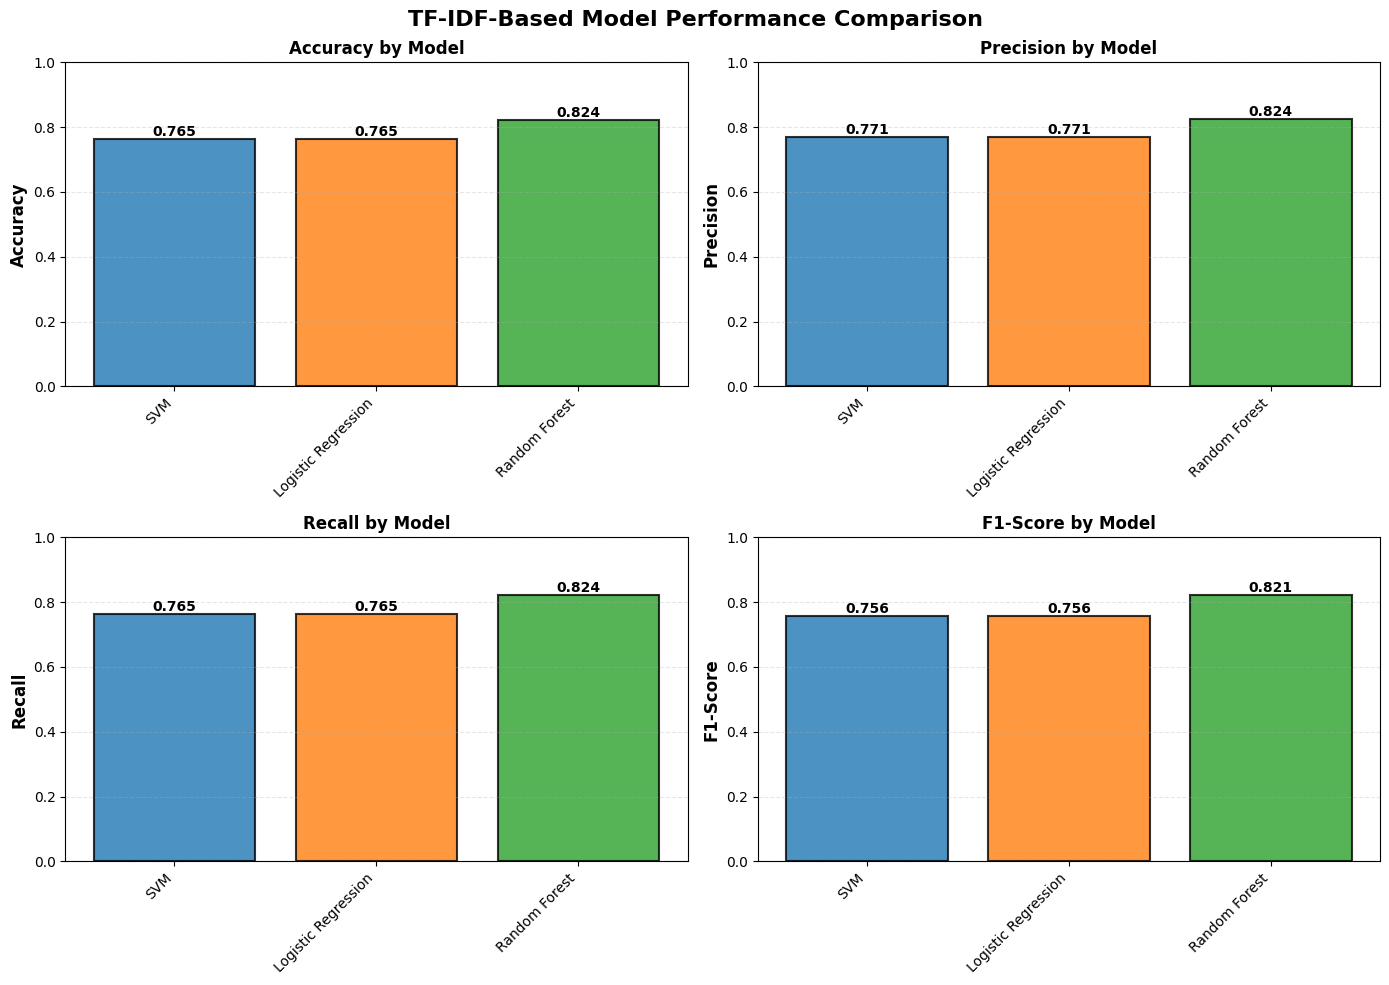

✓ Visualization saved as 'tfidf_models_comparison.png'


In [ ]:
# Create visualization of spaCy models performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('spaCy-Based Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = spacy_comparison[metric].values
    bars = ax.bar(range(len(spacy_comparison)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} by Model', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(spacy_comparison)))
    ax.set_xticklabels([m.replace('spaCy + ', '') for m in spacy_comparison['Model']], rotation=45, ha='right')
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('spacy_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'spacy_models_comparison.png'")


## 7. Confusion Matrices for Each Model

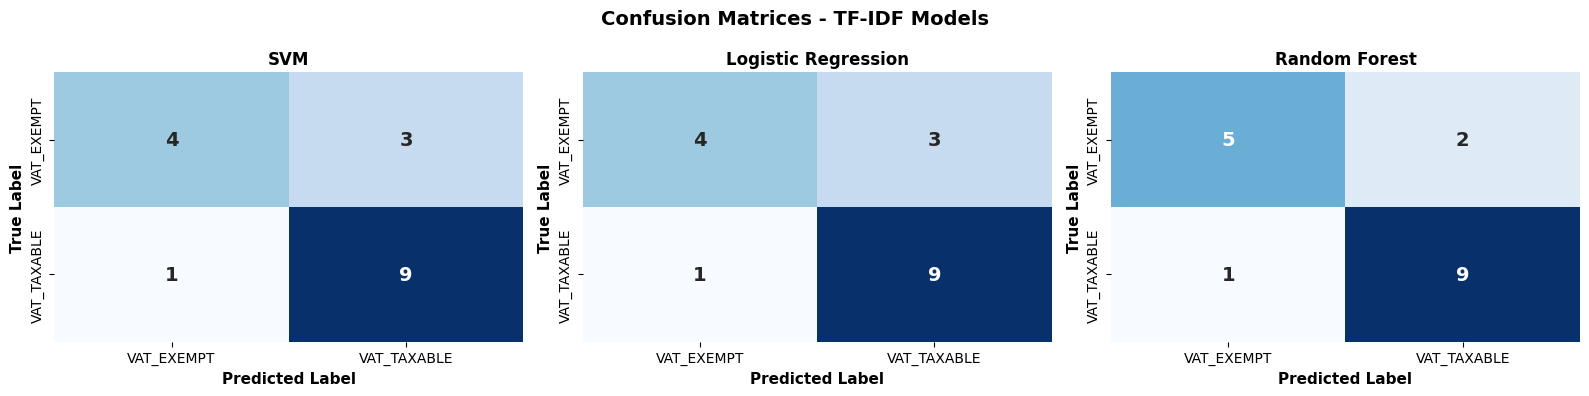

✓ Confusion matrices saved as 'tfidf_confusion_matrices.png'


In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrices for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices - spaCy Models', fontsize=14, fontweight='bold')

for idx, (model_name, model) in enumerate(spacy_models.items()):
    # Get predictions
    y_pred = model.predict(X_test_spacy)
    cm = confusion_matrix(y_test_num, y_pred, labels=[0, 1])
    
    # Plot confusion matrix
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['VAT_EXEMPT', 'VAT_TAXABLE'],
                yticklabels=['VAT_EXEMPT', 'VAT_TAXABLE'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{model_name.replace("spaCy + ", "")}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('spacy_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved as 'spacy_confusion_matrices.png'")


## 8. Apply Best spaCy Model to Full Dataset

In [ ]:
# Select best spaCy model and apply to full dataset
best_model_name = best_spacy_model
best_model = spacy_models[best_model_name]

print(f"\n=== Applying Best spaCy Model to Full Dataset ===")
print(f"Model: {best_model_name}")
print(f"F1-Score: {best_spacy_f1:.4f}")

# Extract spaCy features for all items
print("\nExtracting spaCy features for all items...")
def extract_spacy_features_safe(text):
    try:
        if pd.isna(text) or text == '':
            return np.zeros(96)
        doc = nlp(str(text))
        return doc.vector
    except:
        return np.zeros(96)

all_features_spacy = np.array([extract_spacy_features_safe(text) for text in items_df['item']])
print(f"✓ Features extracted for {len(all_features_spacy)} items")

# Make predictions on full dataset
all_predictions_spacy = best_model.predict(all_features_spacy)
items_df['spacy_vat_class'] = all_predictions_spacy

# Map to labels
items_df['spacy_vat_label'] = items_df['spacy_vat_class'].map({0: 'VAT_EXEMPT', 1: 'VAT_TAXABLE'})

print(f"\n✓ Classification Complete")
print(f"VAT_EXEMPT items: {(items_df['spacy_vat_class'] == 0).sum():,}")
print(f"VAT_TAXABLE items: {(items_df['spacy_vat_class'] == 1).sum():,}")
print(f"Total items: {len(items_df):,}")



=== Applying Best TF-IDF Model to Full Dataset ===
Model: TF-IDF + Random Forest
F1-Score: 0.8209

Extracting TF-IDF features for all items...
✓ Features extracted for 1422 items

✓ Classification Complete
VAT_EXEMPT items: 30
VAT_TAXABLE items: 1,392
Total items: 1,422


## 9. Generate Taxpayer Recommendations from spaCy Model

In [ ]:
# Aggregate VAT classification by taxpayer and generate recommendations
# Choose available key column
if 'ksId' in items_df.columns:
    key_col = 'ksId'
elif 'supplier_tin' in items_df.columns:
    key_col = 'supplier_tin'
else:
    key_col = 'index'
    items_df = items_df.reset_index().rename(columns={'index': 'index'})

# Create a dataset with VAT_TAXABLE items per taxpayer
vat_taxable_items = items_df[items_df['spacy_vat_class'] == 1]
vat_taxable_count = vat_taxable_items.groupby(key_col).size().reset_index(name='vat_taxable_item_count')

# Calculate total items per taxpayer
total_items_count = items_df.groupby(key_col).size().reset_index(name='total_item_count')

# Merge with raw data to get taxpayer info
candidate_cols = ['ksId', 'supplier_tin', 'KSTaxpayerName', 'trade_name', 'KSPhonNumber', 'KSTaxpayerAddress']
available_cols = [c for c in candidate_cols if c in raw_df.columns]
taxpayer_recs_spacy = raw_df[available_cols].copy()
taxpayer_recs_spacy = taxpayer_recs_spacy.merge(vat_taxable_count, left_on=key_col if key_col in taxpayer_recs_spacy.columns else available_cols[0], right_on=key_col, how='left')
taxpayer_recs_spacy = taxpayer_recs_spacy.merge(total_items_count, left_on=key_col if key_col in taxpayer_recs_spacy.columns else available_cols[0], right_on=key_col, how='left')

taxpayer_recs_spacy['vat_taxable_item_count'] = taxpayer_recs_spacy['vat_taxable_item_count'].fillna(0).astype(int)
taxpayer_recs_spacy['total_item_count'] = taxpayer_recs_spacy['total_item_count'].fillna(0).astype(int)

# Calculate percentage of VAT-taxable items
taxpayer_recs_spacy['vat_taxable_percentage'] = taxpayer_recs_spacy.apply(
    lambda row: (row['vat_taxable_item_count'] / row['total_item_count'] * 100) 
    if row['total_item_count'] > 0 else 0, axis=1
)

# Get sample VAT taxable items for each taxpayer
def get_vat_items(key_value):
    items = vat_taxable_items[vat_taxable_items[key_col] == key_value]['item'].head(20).tolist() ##get up to 20 sample items
    return ' | '.join(items) if items else 'N/A'

taxpayer_recs_spacy['sample_vat_items'] = taxpayer_recs_spacy[key_col].apply(get_vat_items)

# Create priority recommendation based on both VAT item count AND percentage
def assign_priority_spacy(row):
    """
    Assign VAT registration priority based on:
    1. Absolute count of VAT taxable items
    2. Percentage of total items that are VAT taxable
    """
    vat_taxable_count = row['vat_taxable_item_count']
    total_items = row['total_item_count']
    percentage_taxable = row['vat_taxable_percentage']
    
    # Handle division by zero
    if total_items == 0:
        return 'NOT_PRIORITY'
    
    # Priority logic: Consider BOTH count AND percentage
    if vat_taxable_count >= 30 and percentage_taxable >= 50:
        return 'CRITICAL'
    elif vat_taxable_count >= 20 and percentage_taxable >= 40:
        return 'HIGH_PRIORITY'
    elif vat_taxable_count >= 10 and percentage_taxable >= 30:
        return 'HIGH_PRIORITY'
    elif vat_taxable_count >= 7 or percentage_taxable >= 25:
        return 'REVIEW_MANUALLY'
    else:
        return 'NOT_PRIORITY'


taxpayer_recs_spacy['recommendation'] = taxpayer_recs_spacy.apply(assign_priority_spacy, axis=1)

# Sort by priority and count
priority_order = {'CRITICAL': 0, 'HIGH_PRIORITY': 1, 'REVIEW_MANUALLY': 2, 'NOT_PRIORITY': 3}
taxpayer_recs_spacy['priority_rank'] = taxpayer_recs_spacy['recommendation'].map(priority_order)
taxpayer_recs_spacy = taxpayer_recs_spacy.sort_values(['priority_rank', 'vat_taxable_item_count'], ascending=[True, False])
taxpayer_recs_spacy = taxpayer_recs_spacy.drop('priority_rank', axis=1)

print(f"\n=== VAT Recruitment Recommendations (spaCy Model) ===")
print(f"\nTotal taxpayers evaluated: {len(taxpayer_recs_spacy):,}")
print(f"Taxpayers with VAT-taxable items: {(taxpayer_recs_spacy['vat_taxable_item_count'] > 0).sum():,}")
print(f"\nRecommendation Breakdown:")
print(taxpayer_recs_spacy['recommendation'].value_counts())
print(f"\nTop 10 Taxpayers for VAT Registration:")
display_cols = [c for c in ['KSTaxpayerName', 'trade_name', 'vat_taxable_item_count', 'total_item_count', 'vat_taxable_percentage', 'recommendation'] if c in taxpayer_recs_spacy.columns]
print(taxpayer_recs_spacy[display_cols].head(10).to_string(index=False))

## 10. Export Results to Excel

In [ ]:
# Export results to Excel files
excel_output_file = 'spacy_model_comparison_results.xlsx'
excel_recs_file = 'KRA_spacy_taxpayer_recommendations.xlsx'

# Export 1: Model comparison metrics
with pd.ExcelWriter(excel_output_file, engine='openpyxl') as writer:
    # Model comparison metrics
    spacy_comparison.to_excel(writer, sheet_name='Model Metrics', index=False)
    
    # Detailed results on test set
    test_results = pd.DataFrame({
        'Actual_Label': y_test,
        'Predicted_Label': best_model.predict(X_test_spacy)
    })
    test_results['Actual_Label'] = test_results['Actual_Label'].map({0: 'VAT_EXEMPT', 1: 'VAT_TAXABLE'})
    test_results['Predicted_Label'] = test_results['Predicted_Label'].map({0: 'VAT_EXEMPT', 1: 'VAT_TAXABLE'})
    test_results.to_excel(writer, sheet_name='Test Predictions', index=False)
    
    # Classification distribution
    class_dist = pd.DataFrame({
        'Classification': ['VAT_EXEMPT', 'VAT_TAXABLE'],
        'Count': [(all_predictions_spacy == 0).sum(), (all_predictions_spacy == 1).sum()],
        'Percentage': [
            f"{((all_predictions_spacy == 0).sum() / len(all_predictions_spacy) * 100):.2f}%",
            f"{((all_predictions_spacy == 1).sum() / len(all_predictions_spacy) * 100):.2f}%"
        ]
    })
    class_dist.to_excel(writer, sheet_name='Classification Distribution', index=False)

print(f"✓ Model metrics exported to: {excel_output_file}")

# Export 2: Taxpayer recommendations
with pd.ExcelWriter(excel_recs_file, engine='openpyxl') as writer:
    # Main recommendations
    taxpayer_recs_spacy.to_excel(writer, sheet_name='Recommendations', index=False)
    
    # Summary by priority
    priority_summary = pd.DataFrame(
        taxpayer_recs_spacy['recommendation'].value_counts().reset_index(name='Count')
    )
    priority_summary.columns = ['Priority', 'Count']
    priority_summary = priority_summary.sort_values('Count', ascending=False)
    priority_summary.to_excel(writer, sheet_name='Priority Summary', index=False)

print(f"✓ Taxpayer recommendations exported to: {excel_recs_file}")
print(f"\nExport completed successfully!")


✓ Model metrics exported to: tfidf_model_comparison_results.xlsx
✓ Taxpayer recommendations exported to: KRA_tfidf_taxpayer_recommendations.xlsx

Export completed successfully!
